In [1]:
%matplotlib widget


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model,metrics,preprocessing

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
train=np.loadtxt("q5_train.csv",skiprows=1,delimiter=",")
test=np.loadtxt("q5_test.csv",skiprows=1,delimiter=",")
X_train, y_train = train[:, :-1], train[:, -1]
X_test, y_test= test[:, :-1], test[:, -1]

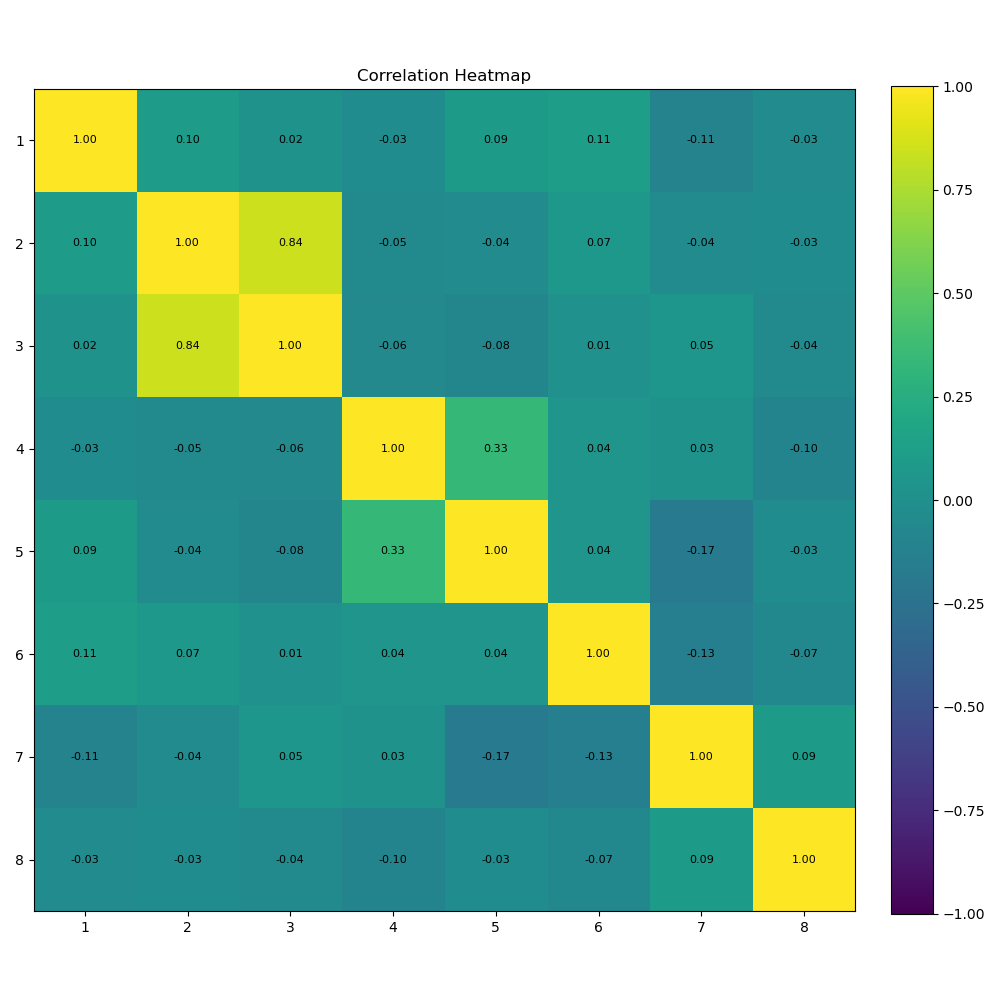

In [4]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

[-0.53050101  1.90111611  0.92090278  0.84520188 -0.72493984 -0.02067353
  0.8199396   0.04904944]
8


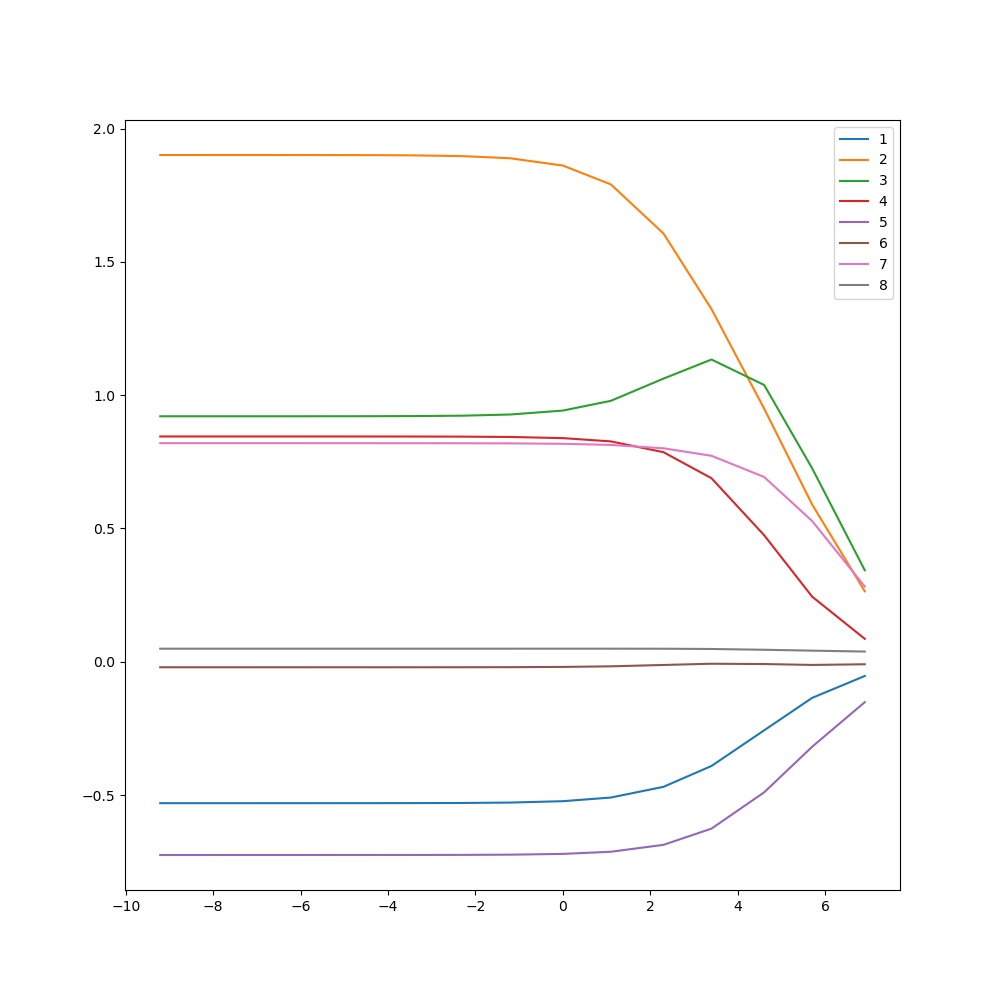

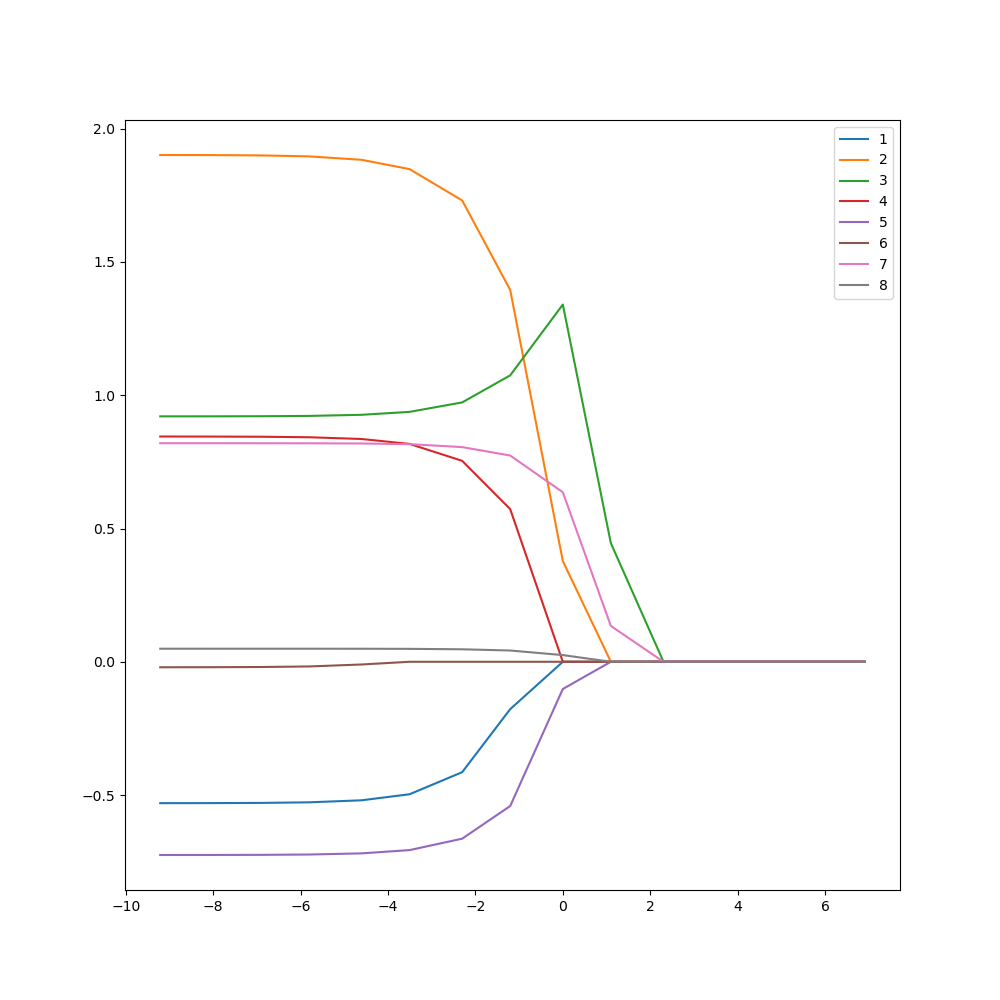

In [5]:
alphas = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
y_pred_ols=reg.predict(X_test)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
y_pred_ridge=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    y_pred_ridge.append(ridge.predict(X_test))
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
# plt.xlim(0, 25)
plt.legend()
plt.show()

coeffs=[]
y_pred_lasso=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    y_pred_lasso.append(lasso.predict(X_test))
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
# plt.xlim(0, 0.2)
plt.legend()
plt.show()


mean squared error: 23441.150109557613 
r2 score: -117.95324959519186 
coefficients (beta): [-0.53050101  1.90111611  0.92090278  0.84520188 -0.72493984 -0.02067353
  0.8199396   0.04904944] 



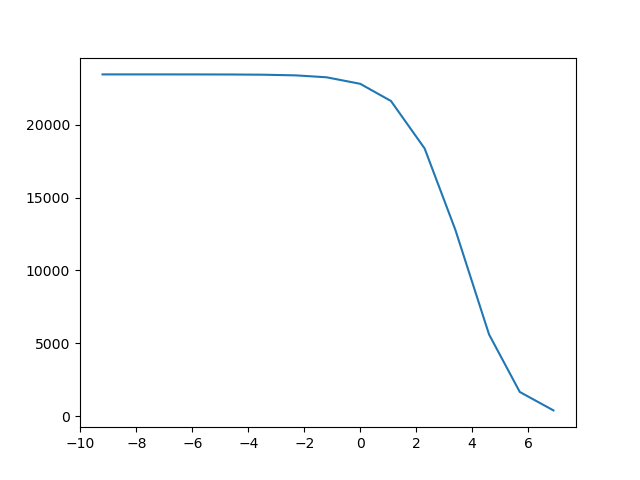

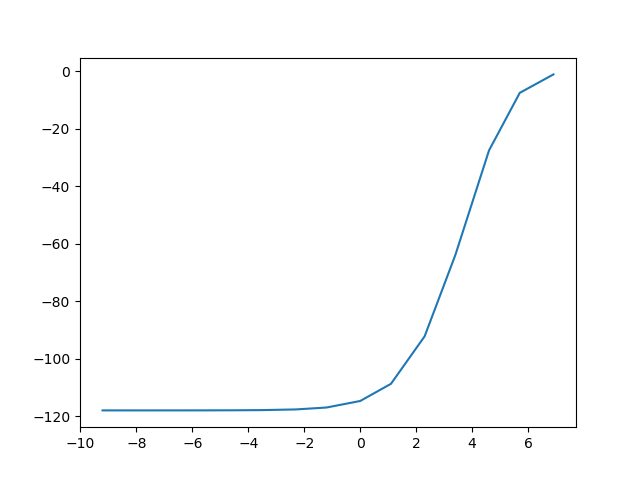

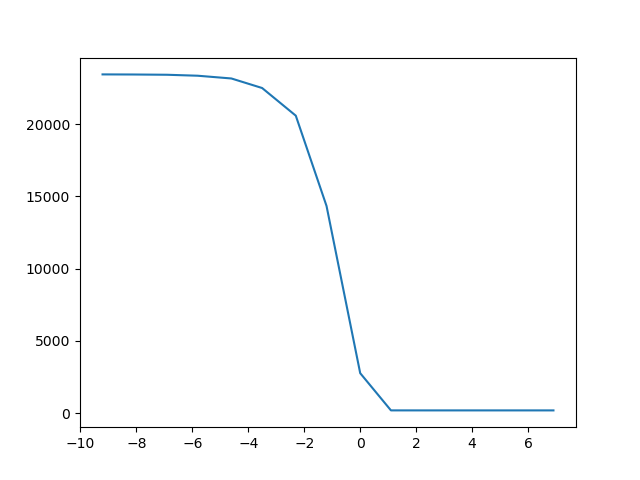

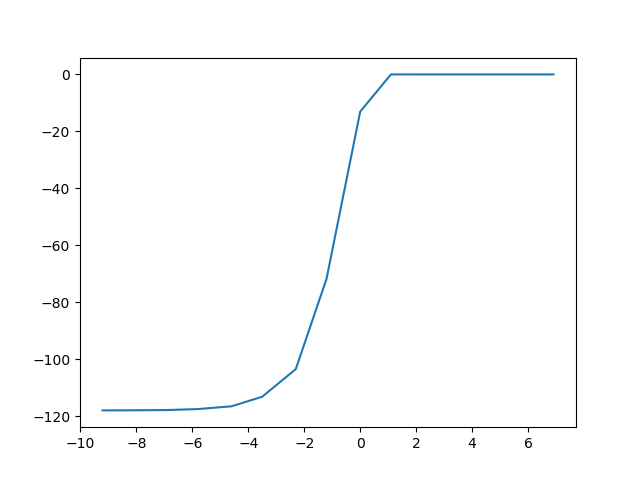

In [6]:
mse_ols=metrics.mean_squared_error(y_test,y_pred_ols)
r2_ols=metrics.r2_score(y_test,y_pred_ols)
print("mean squared error:",mse_ols,"\nr2 score:",r2_ols,"\ncoefficients (beta):",reg.coef_,"\n")

mse_ridge=[]
r2_ridge=[]
n=len(alphas)
for y_pred_row in y_pred_ridge[:n]:
    mse_ridge.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_ridge.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_ridge)
plt.figure()
plt.plot(log_al[:n],r2_ridge)

mse_lasso=[mse_ols]
r2_lasso=[r2_ols]
for y_pred_row in y_pred_lasso[:n-1]:
    mse_lasso.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_lasso.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_lasso)
plt.figure()
plt.plot(log_al[:n],r2_lasso)


# Standardised

In [7]:
std=preprocessing.StandardScaler()
std_X_train=std.fit_transform(X_train)
std_X_test=std.fit_transform(X_test)



[-0.48883183  1.91647411  1.19640014  1.04995919 -1.05937065 -0.01995666
  1.56574968  0.37453933]
8


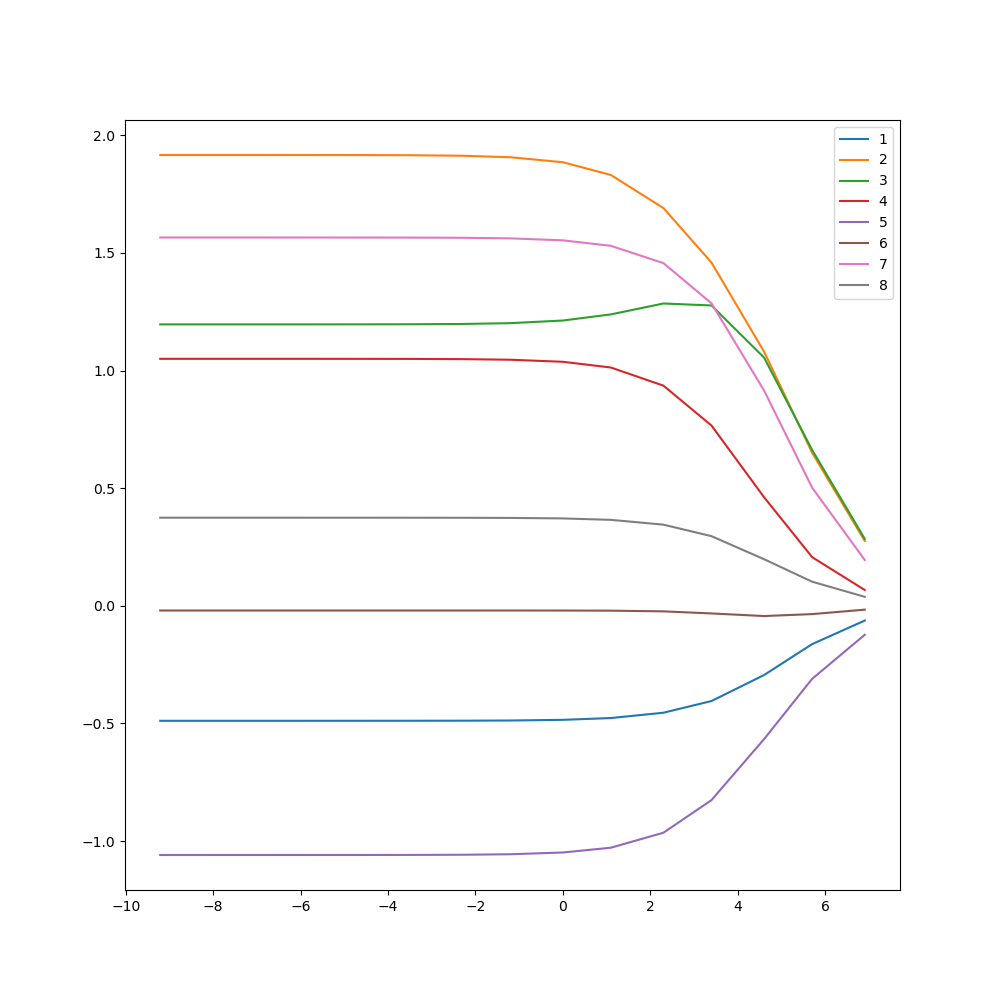

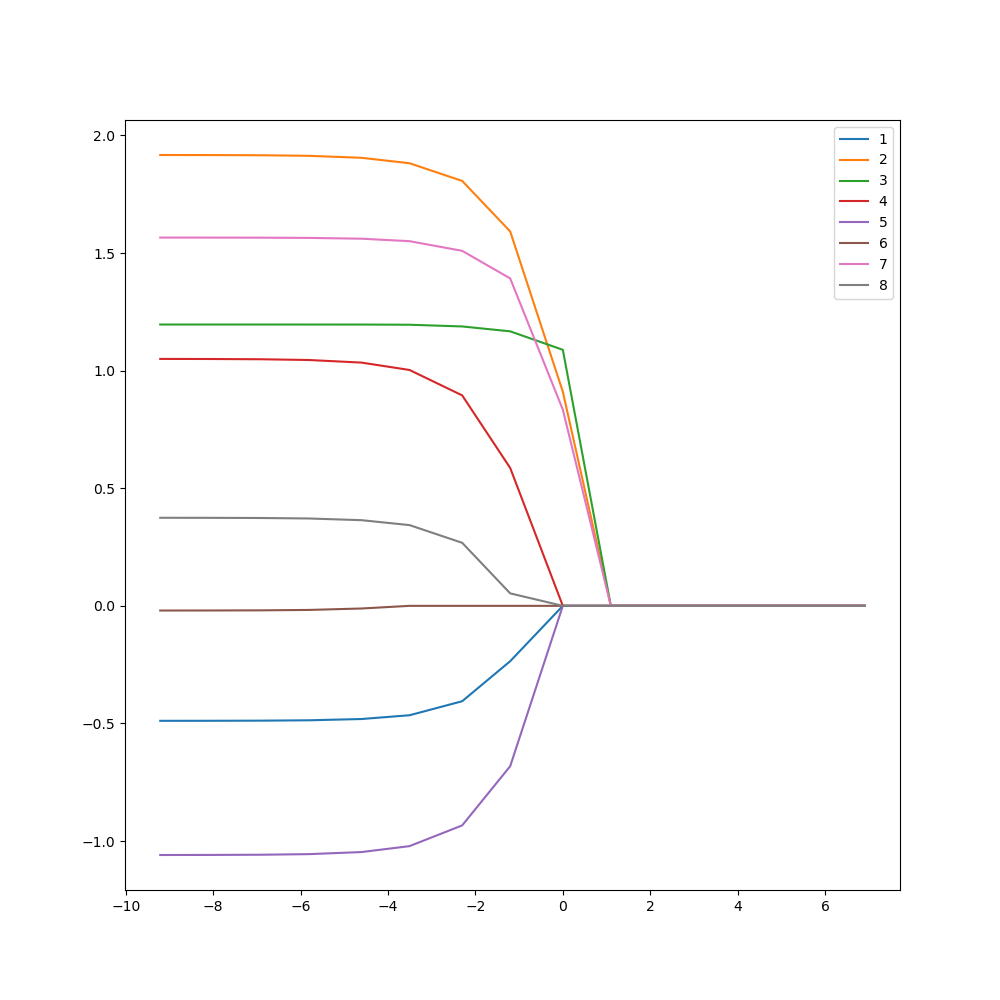

In [8]:
alphas = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(std_X_train,y_train)
y_pred_ols=reg.predict(std_X_test)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
y_pred_ridge=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(std_X_train,y_train)
    y_pred_ridge.append(ridge.predict(std_X_test))
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.legend()
plt.show()

coeffs=[]
y_pred_lasso=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(std_X_train,y_train)
    y_pred_lasso.append(lasso.predict(std_X_test))
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.legend()
plt.show()


mean squared error: 206.65168772285094 
r2 score: -0.04866398082324497 
coefficients (beta): [-0.48883183  1.91647411  1.19640014  1.04995919 -1.05937065 -0.01995666
  1.56574968  0.37453933] 



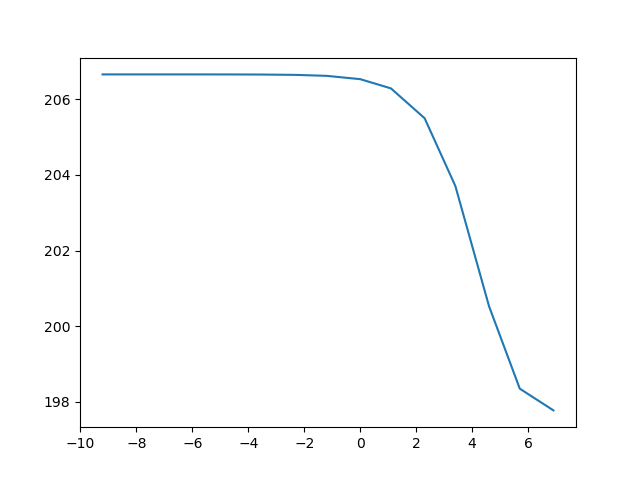

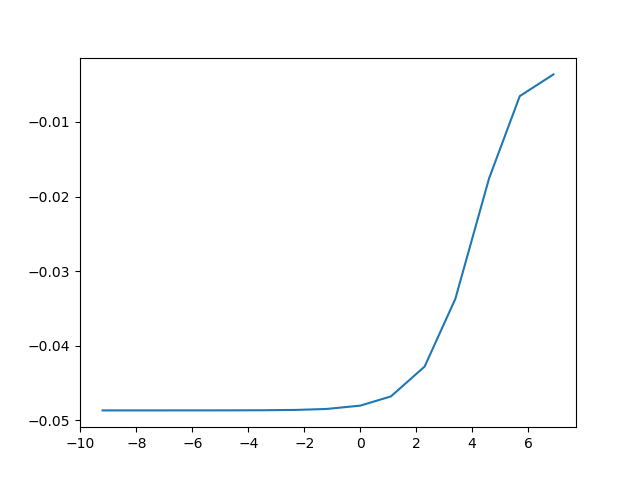

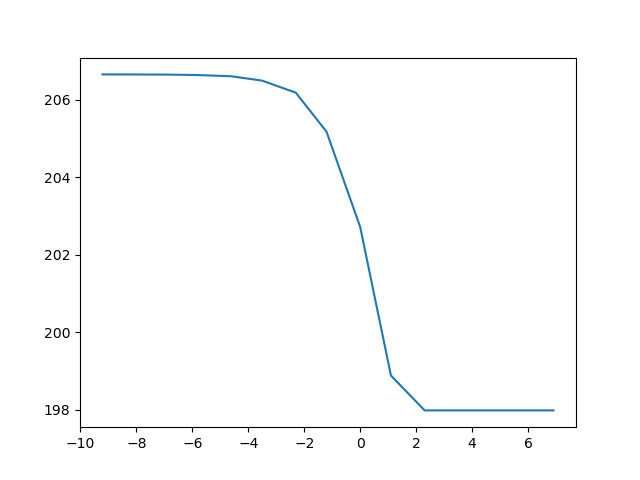

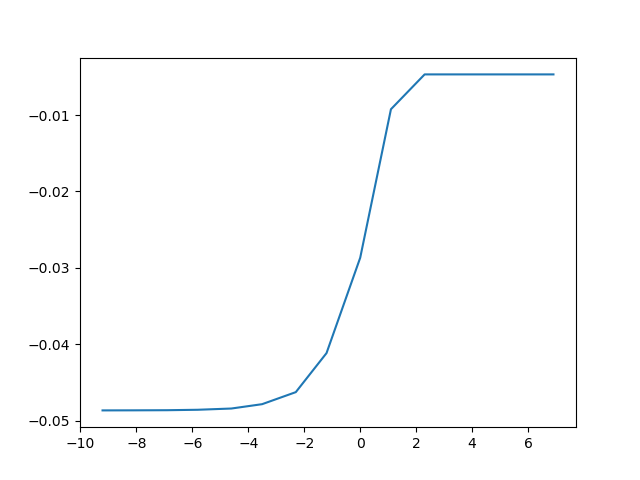

In [9]:
mse_ols=metrics.mean_squared_error(y_test,y_pred_ols)
r2_ols=metrics.r2_score(y_test,y_pred_ols)
print("mean squared error:",mse_ols,"\nr2 score:",r2_ols,"\ncoefficients (beta):",reg.coef_,"\n")

mse_ridge=[]
r2_ridge=[]
n=len(alphas)
for y_pred_row in y_pred_ridge[:n]:
    mse_ridge.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_ridge.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_ridge)
plt.figure()
plt.plot(log_al[:n],r2_ridge)

mse_lasso=[mse_ols]
r2_lasso=[r2_ols]
for y_pred_row in y_pred_lasso[:n-1]:
    mse_lasso.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_lasso.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_lasso)
plt.figure()
plt.plot(log_al[:n],r2_lasso)
